In [205]:
%pip install --upgrade pip
%pip install tensorflow
%pip install numpy
%pip install scipy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [206]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support, log_loss
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, regularizers, callbacks

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


TensorFlow entities such as data shuffling, initialization of model weights, and splitting of data sets often involve some degree of randomness. Without controlling this randomness, each run of your code could lead to slightly different results, which is typically undesirable when comparing models or trying to reproduce results.

In [207]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Deliverable 1: Data Loading and Preprocessing
## 1.1 Load CSV files and convert pixel values into image tensors


In [208]:

# 1.1 Load CSV files
TRAIN_CSV = "sign_mnist_train.csv"
TEST_CSV = "sign_mnist_test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (27455, 785)
Test shape: (7172, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  p

In [209]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# =========================
# Label encoding + image tensor parsing
# =========================

# Fixed configuration constants
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
IMAGE_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Optional alias if later notebook cells still use lowercase
image_shape = IMAGE_SHAPE

LABEL_DTYPE = np.int32
PIXEL_DTYPE = np.float32

# Fit encoder on training labels only
label_encoder = LabelEncoder()
train_labels_raw = train_df["label"].to_numpy(dtype=LABEL_DTYPE)
test_labels_raw = test_df["label"].to_numpy(dtype=LABEL_DTYPE)

label_encoder.fit(train_labels_raw)

# Make sure test labels do not contain unseen classes
assert set(test_labels_raw).issubset(set(label_encoder.classes_)), \
    "Test set contains labels not seen in training set."

def parse_df(df, encoder, image_shape):
    raw_labels = df["label"].to_numpy(dtype=LABEL_DTYPE)
    labels = encoder.transform(raw_labels).astype(LABEL_DTYPE)

    pixels = df.drop("label", axis=1).to_numpy(dtype=PIXEL_DTYPE)
    images = pixels.reshape(-1, *image_shape)

    return images, labels

# Parse data into raw image tensors + encoded labels
X_train_raw, y_train_full = parse_df(train_df, label_encoder, IMAGE_SHAPE)
X_test_raw, y_test = parse_df(test_df, label_encoder, IMAGE_SHAPE)

# If other cells expect these names, initialize them here
X_train_full = X_train_raw.copy()
X_test_full = X_test_raw.copy()

num_classes = len(label_encoder.classes_)

# Sign Language MNIST raw labels map naturally to letters
target_names = [chr(ord("A") + int(raw_label)) for raw_label in label_encoder.classes_]
idx_to_letter = {i: target_names[i] for i in range(num_classes)}

print("Raw classes seen by encoder:", label_encoder.classes_)
print("Number of classes:", num_classes)
print("Target names:", target_names)
print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("Pixel range before normalization:", X_train_raw.min(), X_train_raw.max())

Raw classes seen by encoder: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Number of classes: 24
Target names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
X_train_raw shape: (27455, 28, 28, 1)
X_test_raw shape: (7172, 28, 28, 1)
Pixel range before normalization: 0.0 255.0


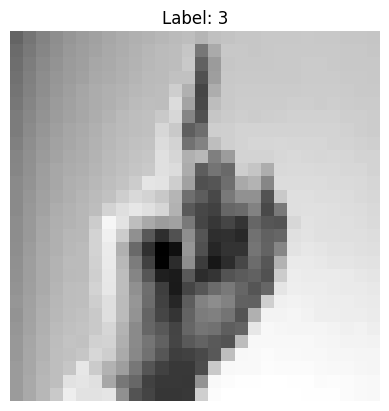

In [210]:
import matplotlib.pyplot as plt
plt.imshow(X_train_full[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train_full[0]}")
plt.axis("off")
plt.show()

## 1.2 Normalize to 0, 1


In [211]:
# =========================
# Normalize to [0,1] + optional per-image whitening
# =========================

# Always rebuild from raw tensors so this cell is safe to rerun
X_train_full = X_train_raw / 255.0
X_test_full = X_test_raw / 255.0

# Keep an unwhitened copy for plotting
X_test_display = X_test_full.copy()

APPLY_WHITENING = True

def per_image_whiten(images):
    means = np.mean(images, axis=(1, 2, 3), keepdims=True)
    stds = np.std(images, axis=(1, 2, 3), keepdims=True)
    stds = np.maximum(stds, 1e-6)
    return (images - means) / stds

if APPLY_WHITENING:
    X_train_full = per_image_whiten(X_train_full)
    X_test_full = per_image_whiten(X_test_full)

print("After preprocessing:")
print("Train min:", X_train_full.min(), "Train max:", X_train_full.max())
print("Test min:", X_test_full.min(), "Test max:", X_test_full.max())
print("Display copy min:", X_test_display.min(), "Display copy max:", X_test_display.max())

After preprocessing:
Train min: -6.086524 Train max: 3.5141728
Test min: -6.318919 Test max: 3.154873
Display copy min: 0.0 Display copy max: 1.0


## 1.3 Create Validation split and Training set

In [212]:
VALIDATION_SPLIT = 0.20

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test_full.shape, y_test.shape)

Training set: (21964, 28, 28, 1) (21964,)
Validation set: (5491, 28, 28, 1) (5491,)
Test set: (7172, 28, 28, 1) (7172,)


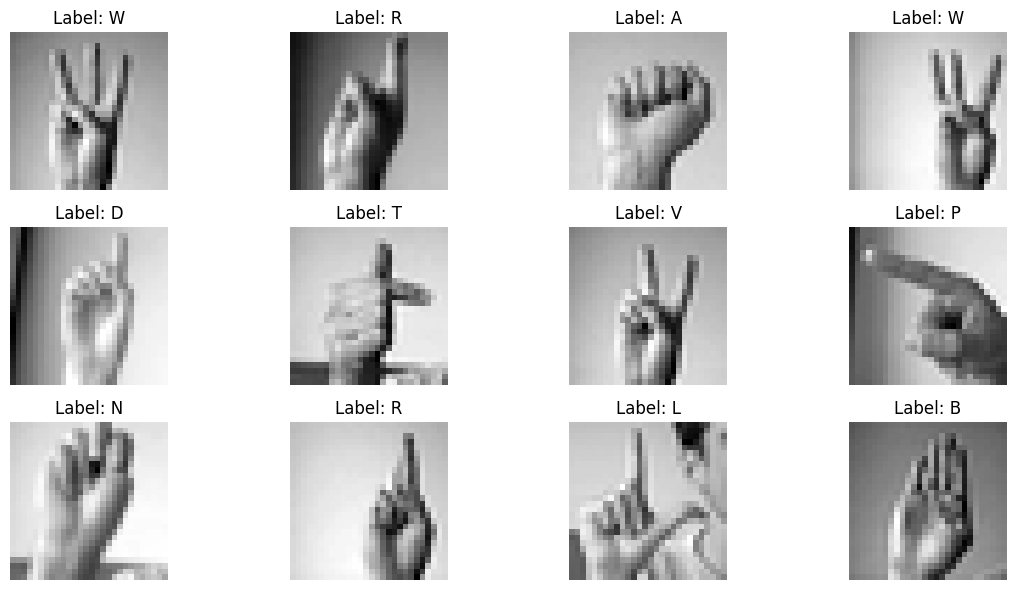

In [213]:
# 9. Visualize sample images
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    
    img = X_train[i].squeeze()
    
    # If whitening is enabled, rescale for display only
    img_display = (img - img.min()) / (img.max() - img.min() + 1e-8)
    
    plt.imshow(img_display, cmap="gray")
    plt.title(f"Label: {idx_to_letter[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [214]:
# 10. Build tf.data datasets
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)
test_ds = make_dataset(X_test_full, y_test, training=False)

In [215]:
# 11. Safe data augmentation
# Small rotations, zoom, and translation are usually safe.
# Horizontal flipping is intentionally NOT used because sign gestures
# may be handedness-sensitive.

rotation_factor = 0.03   # about ±10 degrees
zoom_factor = 0.15
translation_factor = 0.10

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=rotation_factor, fill_mode="nearest"),
    layers.RandomZoom(height_factor=zoom_factor, width_factor=zoom_factor, fill_mode="nearest"),
    layers.RandomTranslation(
        height_factor=translation_factor,
        width_factor=translation_factor,
        fill_mode="nearest"
    ),
], name="data_augmentation")

In [216]:
from typing import Literal

def conv_bn_relu(
    x,
    filters: int,
    kernel_size,
    l2_reg,
    padding: Literal["same", "valid"] = "same"
):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=kernel_size,
        padding=padding,
        kernel_regularizer=l2_reg
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

# CNN Architectures
## 2.1 Define a baseline CNN


In [217]:
# 13. Model A: Baseline CNN (LeNet-style)
def build_model_a(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)
    
    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)
    
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Model_A_Baseline_LeNet")
    return model

## 2.2 Enhanced CNN architectures


In [218]:
# 14. Model B: AlexNet-inspired deeper CNN
def build_model_b(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)

    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)

    # Conv 1
    x = conv_bn_relu(x, 32, (3, 3), l2_reg)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same")(x)

    # Conv 2
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding="same")(x)

    # Conv 3
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)

    # Conv 4
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)

    # Conv 5
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)

    # Lighter classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="Model_B_AlexNet_Inspired")
    return model

In [219]:
# 15. Model C: Compact VGG-style CNN
def build_model_c(image_shape, num_classes, data_augmentation, dropout_rate, weight_decay):
    l2_reg = regularizers.l2(weight_decay)
    
    inputs = layers.Input(shape=image_shape)
    x = data_augmentation(inputs)
    
    # Block 1
    x = conv_bn_relu(x, 32, (3, 3), l2_reg)
    x = conv_bn_relu(x, 32, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 2
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)
    x = conv_bn_relu(x, 64, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 3
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    x = conv_bn_relu(x, 128, (3, 3), l2_reg)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2_reg)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs, outputs, name="Model_C_Compact_VGG")
    return model

## Justify design choices


In [220]:
#  Build model dictionary
DROPOUT_RATE = 0.5
WEIGHT_DECAY = 5e-4

model_builders = {
    "Model A - Baseline CNN": lambda: build_model_a(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    ),
    "Model B - AlexNet-inspired CNN": lambda: build_model_b(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    ),
    "Model C - Compact VGG-style CNN": lambda: build_model_c(
        image_shape=image_shape,
        num_classes=num_classes,
        data_augmentation=data_augmentation,
        dropout_rate=DROPOUT_RATE,
        weight_decay=WEIGHT_DECAY
    )
}

# Inspect model summaries
for model_name, builder in model_builders.items():
    print("\n" + "=" * 80)
    print(model_name)
    model = builder()
    model.summary()


Model A - Baseline CNN


Model: "Model_A_Baseline_LeNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_42 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_153 (Conv2D)             │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_154 (Conv2D)             │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,448 (1.62 MB)

 Trainable params: 423,448 (1.62 MB)

...

Model: "Model_C_Compact_VGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_45 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_160 (Conv2D)             │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_130         │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_130 (ReLU)                │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_161 (Conv2D)             │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_131         │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_131 (ReLU)                │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_162 (Conv2D)             │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_132         │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_132 (ReLU)                │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_163 (Conv2D)             │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_133         │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_133 (ReLU)                │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_164 (Conv2D)             │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_134         │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_134 (ReLU)                │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_165 (Conv2D)             │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_135         │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_135 (ReLU)                │ (None, 7, 7, 128)      │             

 Total params: 307,832 (1.17 MB)

 Trainable params: 306,936 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [221]:
# 17. Compile helper and callbacks
def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def safe_filename(name):
    return "".join(ch if ch.isalnum() else "_" for ch in name)

def get_callbacks(model_name, early_stop_patience, lr_patience, min_lr):
    file_name = f"best_{safe_filename(model_name)}.keras"
    
    return [
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=early_stop_patience,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.1,
            patience=lr_patience,
            min_lr=min_lr,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            file_name,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        )
    ]

# Deliverable 3: Training, Testing, and Evaluation

## 3.1 Hyperparameter tuning

In [222]:
# 18. Training function
def train_and_evaluate(
    model_name,
    model_builder,
    train_ds,
    val_ds,
    test_ds,
    learning_rate,
    epochs,
    early_stop_patience,
    lr_patience,
    min_lr,
    use_class_weights=False,
    class_weight_dict=None
):
    print("\n" + "=" * 100)
    print(f"Training {model_name}")
    print("=" * 100)
    
    model = model_builder()
    model = compile_model(model, learning_rate=learning_rate)
    
    start_time = time.time()
    
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(
            model_name=model_name,
            early_stop_patience=early_stop_patience,
            lr_patience=lr_patience,
            min_lr=min_lr
        ),
        class_weight=class_weight_dict if use_class_weights else None,
        verbose=1
    )
    
    end_time = time.time()
    training_time = end_time - start_time
    
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    result = {
        "model": model_name,
        "params": model.count_params(),
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "best_val_loss": min(history.history["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "training_time_sec": training_time
    }
    
    return model, history, result

In [ ]:
# 19. Train all three models
EPOCHS = 30
LEARNING_RATE = 1e-3

# Extra training controls kept here because they belong to training
EARLY_STOP_PATIENCE = 6
LR_PATIENCE = 3
MIN_LR = 1e-6

trained_models = {}
histories = {}
results = []

for model_name, builder in model_builders.items():
    model, history, result = train_and_evaluate(
        model_name=model_name,
        model_builder=builder,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        learning_rate=LEARNING_RATE,
        epochs=EPOCHS,
        early_stop_patience=EARLY_STOP_PATIENCE,
        lr_patience=LR_PATIENCE,
        min_lr=MIN_LR,
        use_class_weights=False,   )
    
    trained_models[model_name] = model
    histories[model_name] = history
    results.append(result)


Training Model A - Baseline CNN
Epoch 1/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3124 - loss: 2.3962
Epoch 1: val_accuracy improved from None to 0.90894, saving model to best_Model_A___Baseline_CNN.keras

Epoch 1: finished saving model to best_Model_A___Baseline_CNN.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4812 - loss: 1.7863 - val_accuracy: 0.9089 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 2/30
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7368 - loss: 0.9320
Epoch 2: val_accuracy improved from 0.90894 to 0.97104, saving model to best_Model_A___Baseline_CNN.keras

Epoch 2: finished saving model to best_Model_A___Baseline_CNN.keras
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7691 - loss: 0.8476 - val_accuracy: 0.9710 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 3/30
342/344 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8331 - loss: 0.6730
Epoch 3: val_accuracy improved from 0.97104 to 0.98762, saving model to best_Mod

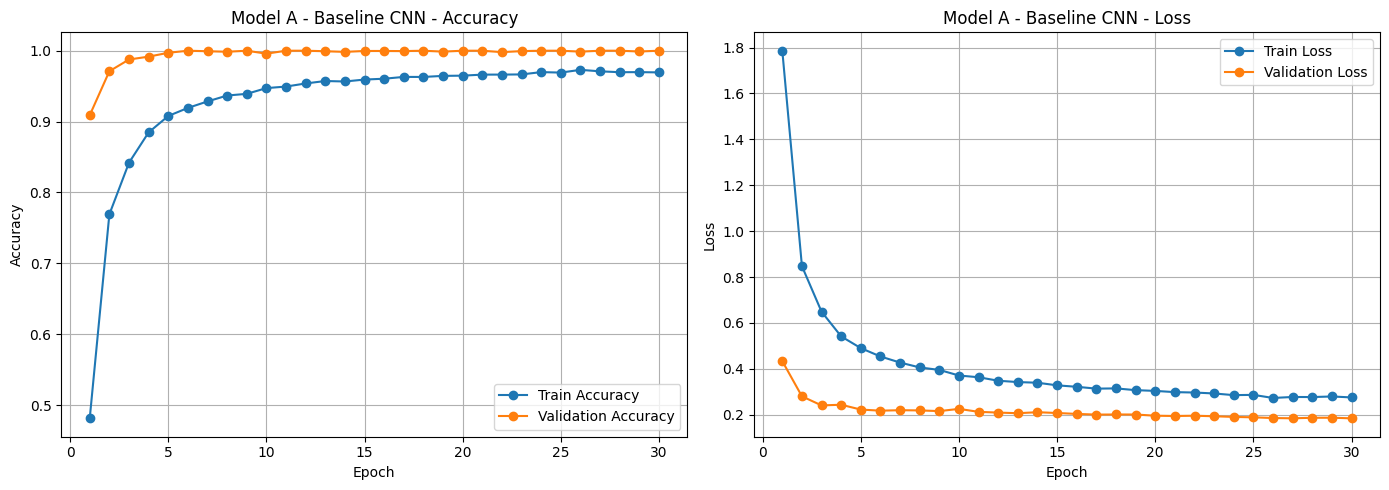

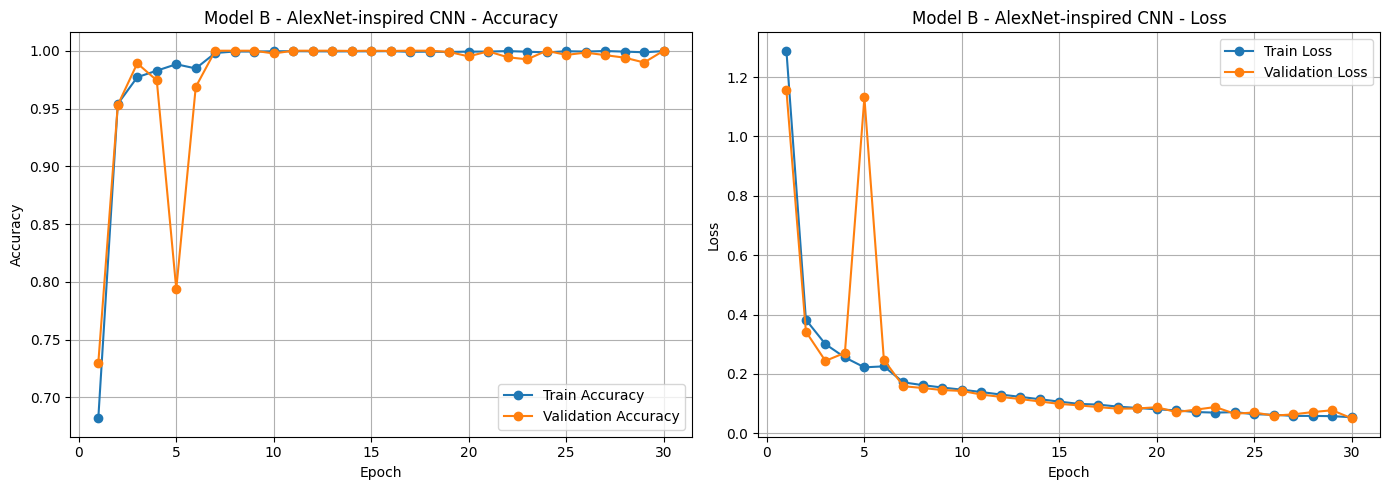

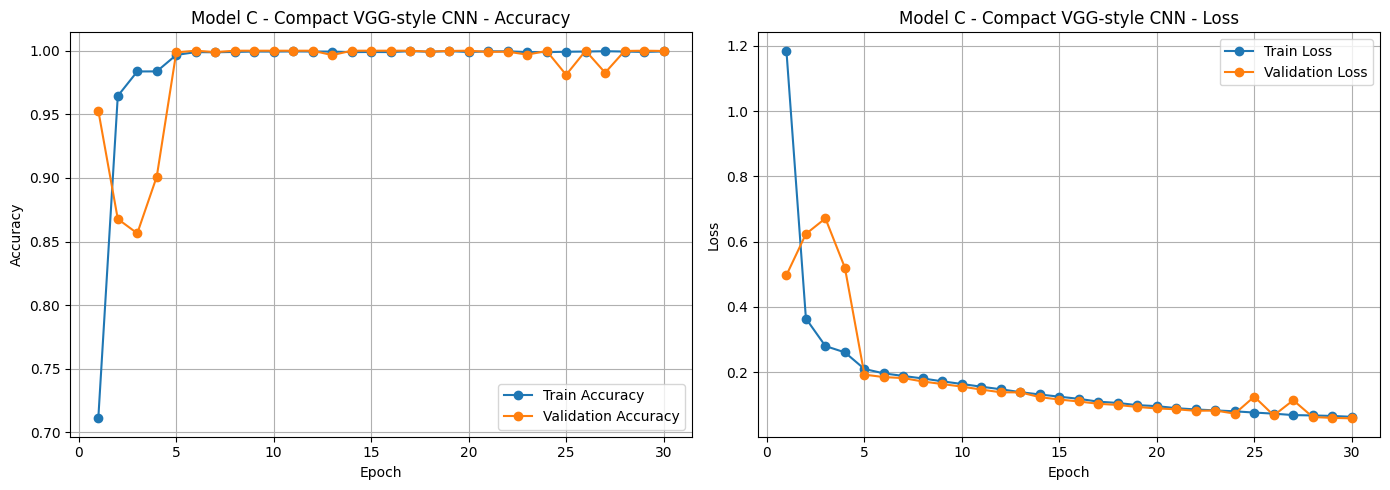

In [ ]:
# 21. Plot training history
def plot_history(history, model_name):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, marker="o", label="Train Accuracy")
    plt.plot(epochs_range, val_acc, marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.title(f"{model_name} - Accuracy")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, marker="o", label="Train Loss")
    plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

for model_name, history in histories.items():
    plot_history(history, model_name)

In [225]:
# 22. Predict test labels for all 3 models
all_predictions = {}
all_probabilities = {}

for model_name, model in trained_models.items():
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    
    all_probabilities[model_name] = y_prob
    all_predictions[model_name] = y_pred

print("Predictions generated for:")
for model_name in all_predictions:
    print("-", model_name)

Predictions generated for:
- Model A - Baseline CNN
- Model B - AlexNet-inspired CNN
- Model C - Compact VGG-style CNN


In [226]:
# =========================
# Classification report for all 3 models
# =========================
from sklearn.metrics import classification_report
import pandas as pd

# Human-readable class names
target_names = [idx_to_letter[i] for i in range(num_classes)]

# Store reports if you want to inspect or export them later
all_reports = {}

for model_name, y_pred in all_predictions.items():
    print("\n" + "=" * 100)
    print(f"Classification Report - {model_name}")
    print("=" * 100)

    # Plain text report
    report_text = classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
    print(report_text)

    # DataFrame version
    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()
    all_reports[model_name] = report_df

    print("DataFrame version:")
    print(report_df.round(4))


Classification Report - Model A - Baseline CNN
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       331
           B     1.0000    0.9630    0.9811       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    1.0000    1.0000       245
           E     1.0000    1.0000    1.0000       498
           F     1.0000    1.0000    1.0000       247
           G     1.0000    1.0000    1.0000       348
           H     1.0000    1.0000    1.0000       436
           I     1.0000    1.0000    1.0000       288
           K     0.9511    1.0000    0.9750       331
           L     1.0000    1.0000    1.0000       209
           M     1.0000    1.0000    1.0000       394
           N     1.0000    1.0000    1.0000       291
           O     1.0000    1.0000    1.0000       246
           P     1.0000    1.0000    1.0000       347
           Q     1.0000    1.0000    1.0000       164
           R     1.0000    1.0000

In [227]:
# Final comparison table for all 3 models
# Columns:
# - Model
# - Parameters
# - Best validation accuracy
# - Test accuracy
# - Test loss
# - Log loss
# - Macro F1
# - Weighted F1
# - Training time

# Training summary from the training loop
training_df = pd.DataFrame(results)

# Build evaluation metrics from predictions
evaluation_rows = []

for model_name, model in trained_models.items():
    y_pred = all_predictions[model_name]
    y_prob = all_probabilities[model_name]

    # Keras test loss / accuracy
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    # sklearn metrics
    accuracy = accuracy_score(y_test, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    # Multiclass log loss from predicted probabilities
    test_log_loss = log_loss(y_test, y_prob, labels=np.arange(num_classes))

    evaluation_rows.append({
        "model": model_name,
        "test_accuracy_eval": accuracy,
        "test_loss_eval": test_loss,
        "log_loss": test_log_loss,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

evaluation_df = pd.DataFrame(evaluation_rows)

# Merge training + evaluation
final_comparison_df = training_df.merge(evaluation_df, on="model", how="left")

# Keep only the requested columns and rename them cleanly
final_comparison_df = final_comparison_df[[
    "model",
    "params",
    "best_val_accuracy",
    "test_accuracy_eval",
    "test_loss_eval",
    "log_loss",
    "macro_f1",
    "weighted_f1",
    "training_time_sec"
]].copy()

final_comparison_df = final_comparison_df.rename(columns={
    "model": "Model",
    "params": "Parameters",
    "best_val_accuracy": "Best Validation Accuracy",
    "test_accuracy_eval": "Test Accuracy",
    "test_loss_eval": "Test Loss",
    "log_loss": "Log Loss",
    "macro_f1": "Macro F1",
    "weighted_f1": "Weighted F1",
    "training_time_sec": "Training Time (sec)"
})

# Round numeric columns for readability
for col in [
    "Best Validation Accuracy",
    "Test Accuracy",
    "Test Loss",
    "Log Loss",
    "Macro F1",
    "Weighted F1",
    "Training Time (sec)"
]:
    final_comparison_df[col] = final_comparison_df[col].round(4)

print(final_comparison_df)

                             Model  Parameters  Best Validation Accuracy  \
0           Model A - Baseline CNN      423448                       1.0   
1   Model B - AlexNet-inspired CNN      327128                       1.0   
2  Model C - Compact VGG-style CNN      307832                       1.0   

   Test Accuracy  Test Loss  Log Loss  Macro F1  Weighted F1  \
0         0.9954     0.1959    0.0122    0.9955       0.9954   
1         1.0000     0.0523    0.0025    1.0000       1.0000   
2         0.9999     0.0608    0.0033    0.9999       0.9999   

   Training Time (sec)  
0              82.6125  
1             547.6169  
2             639.0445  


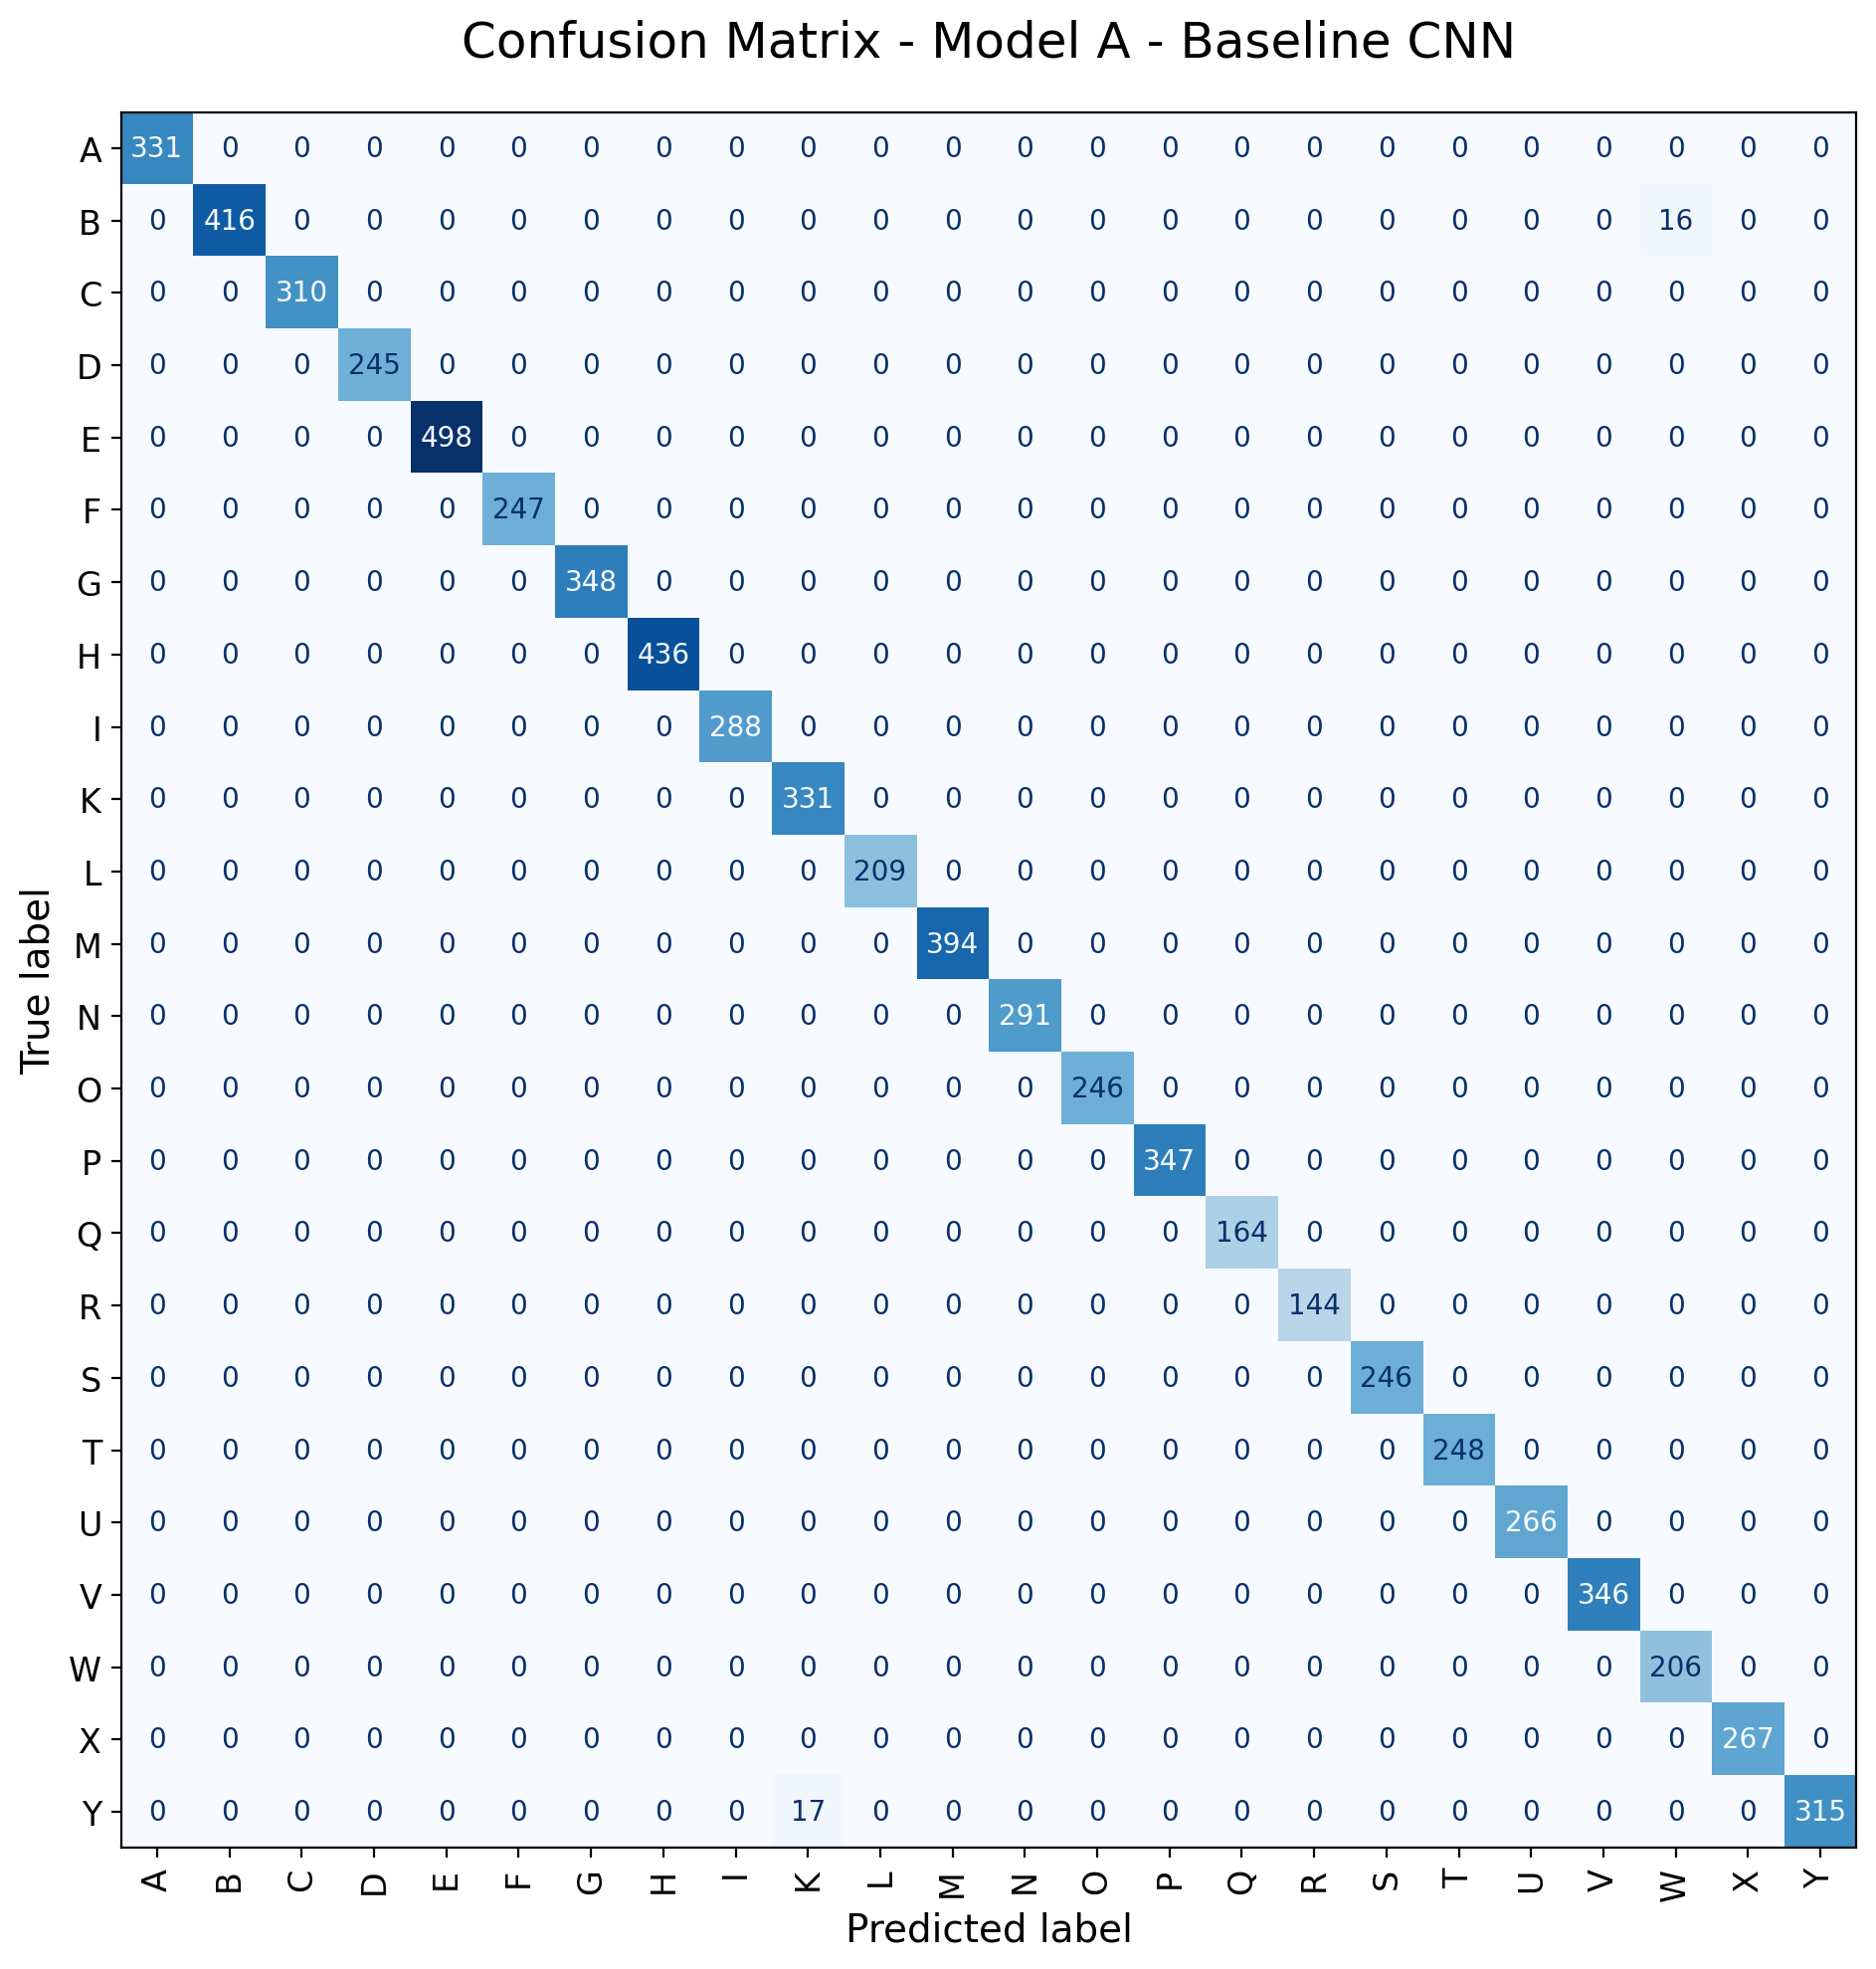

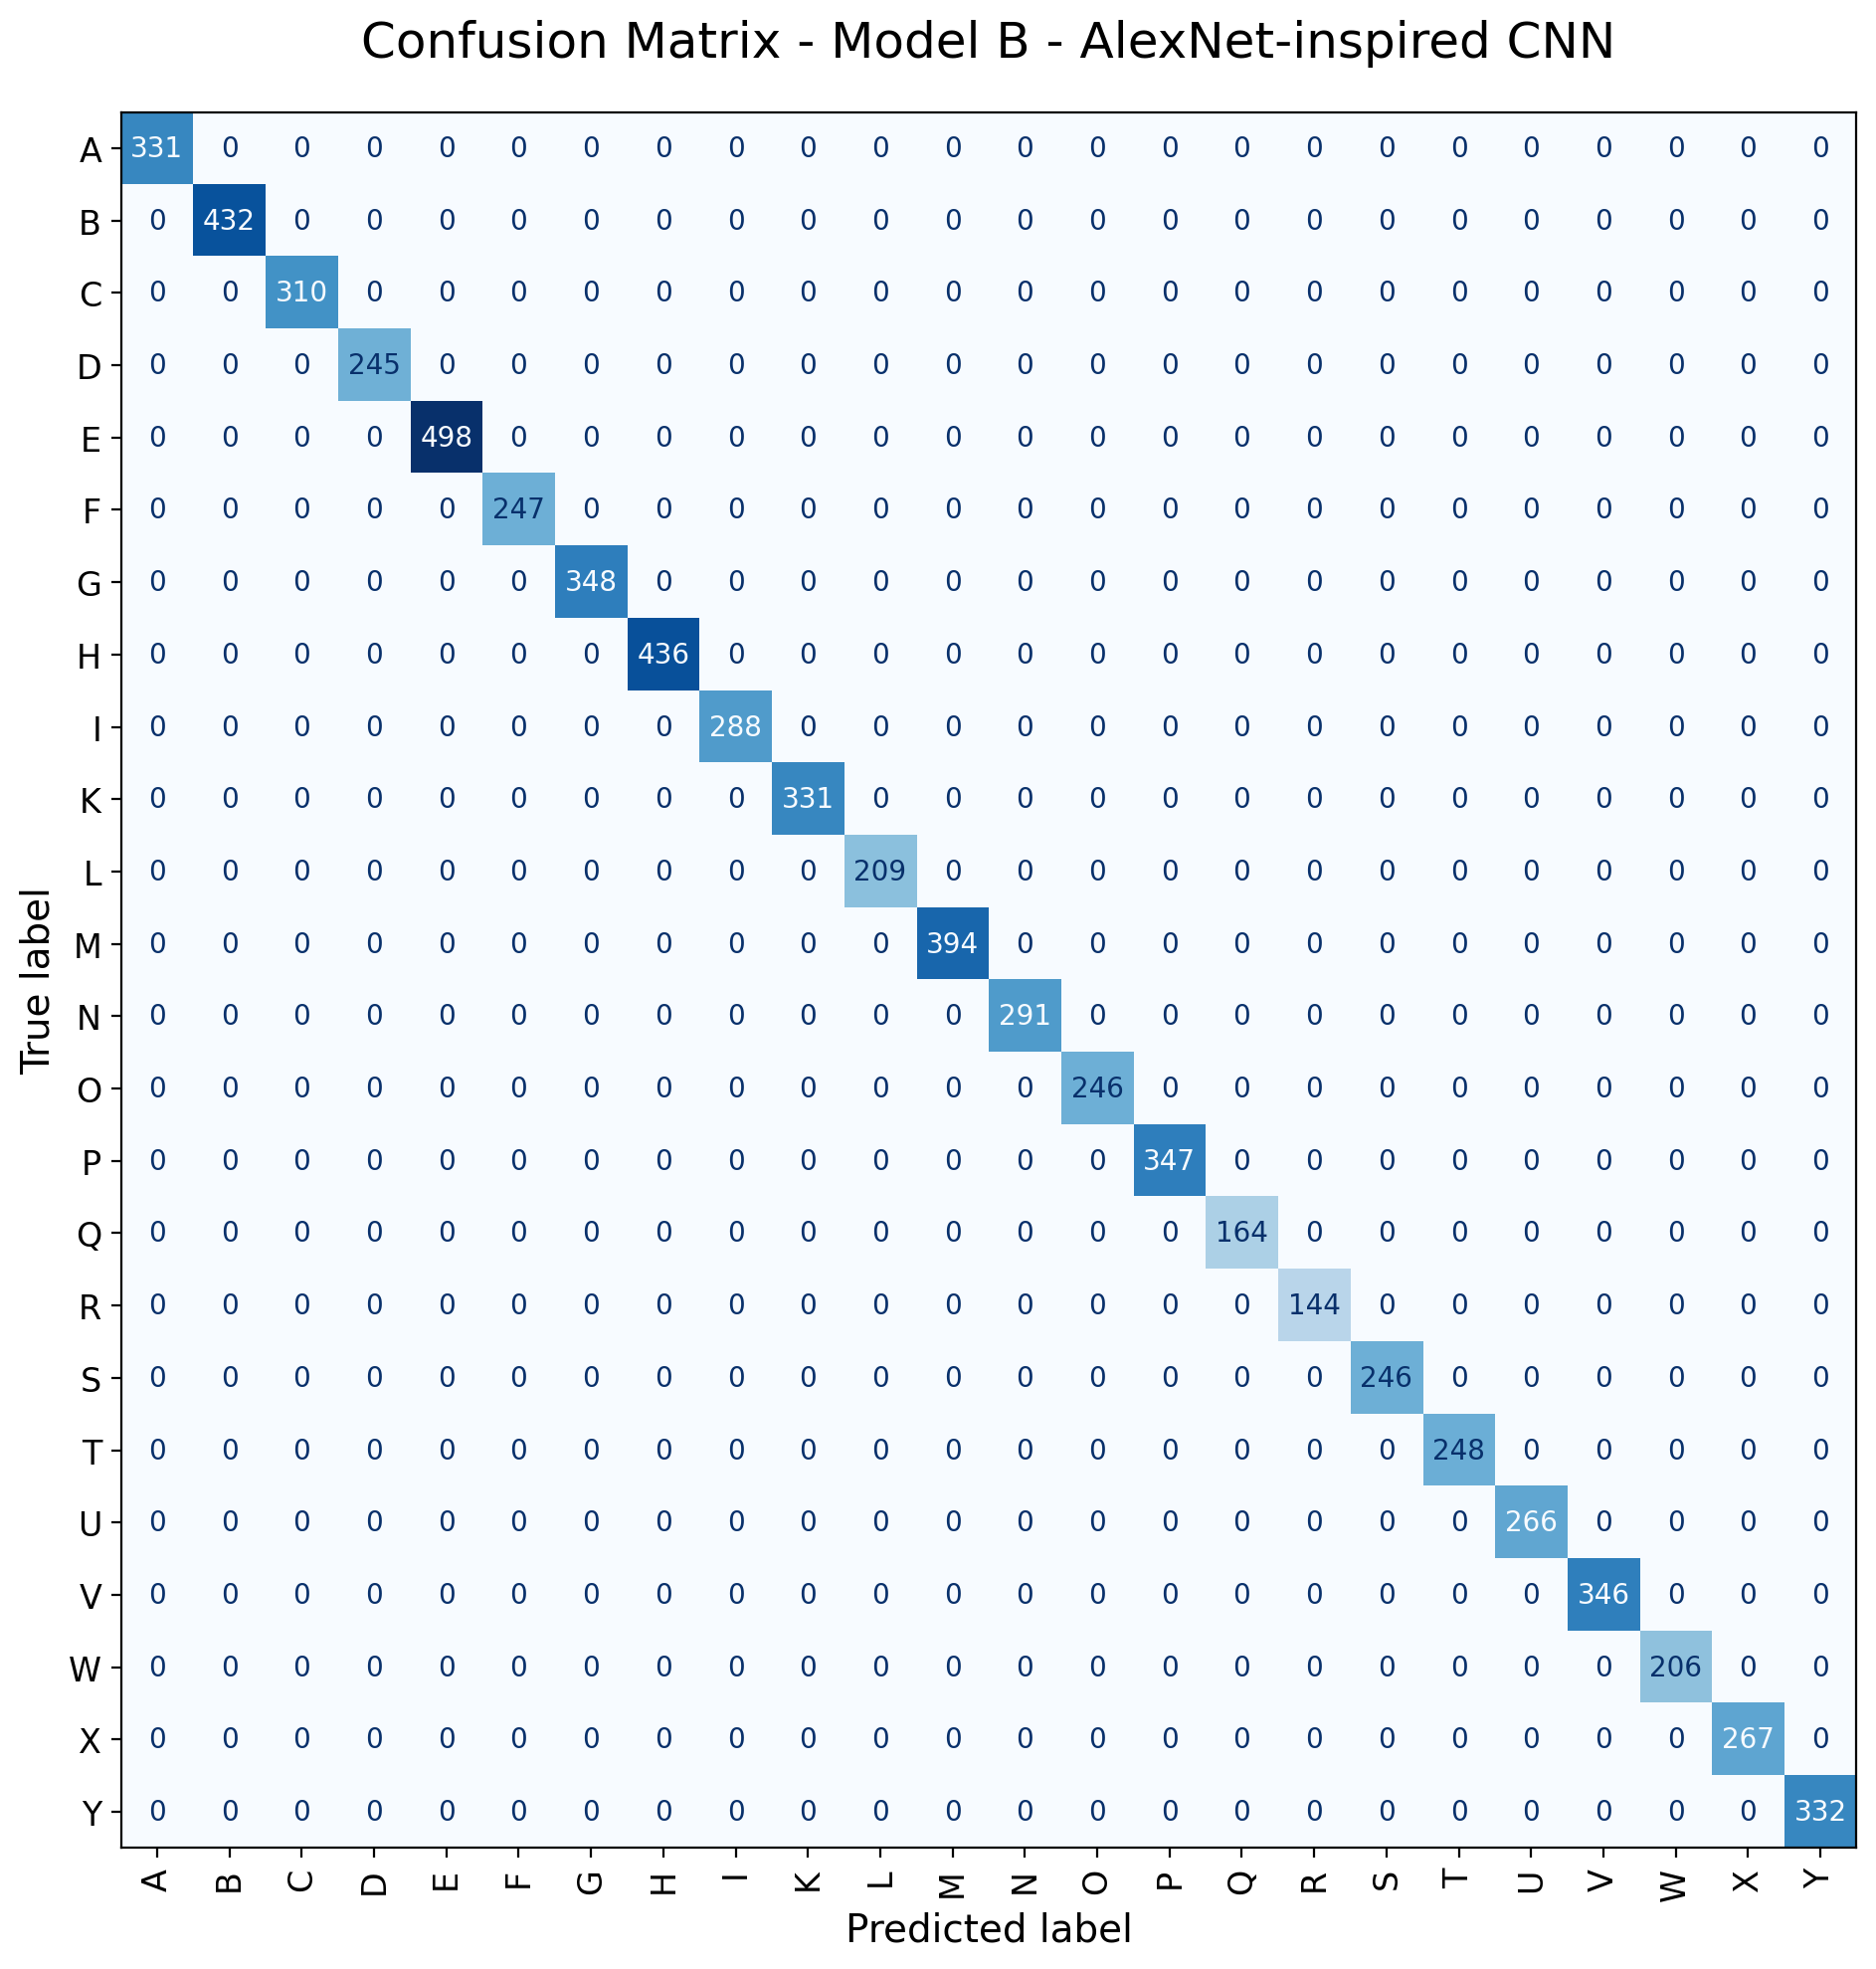

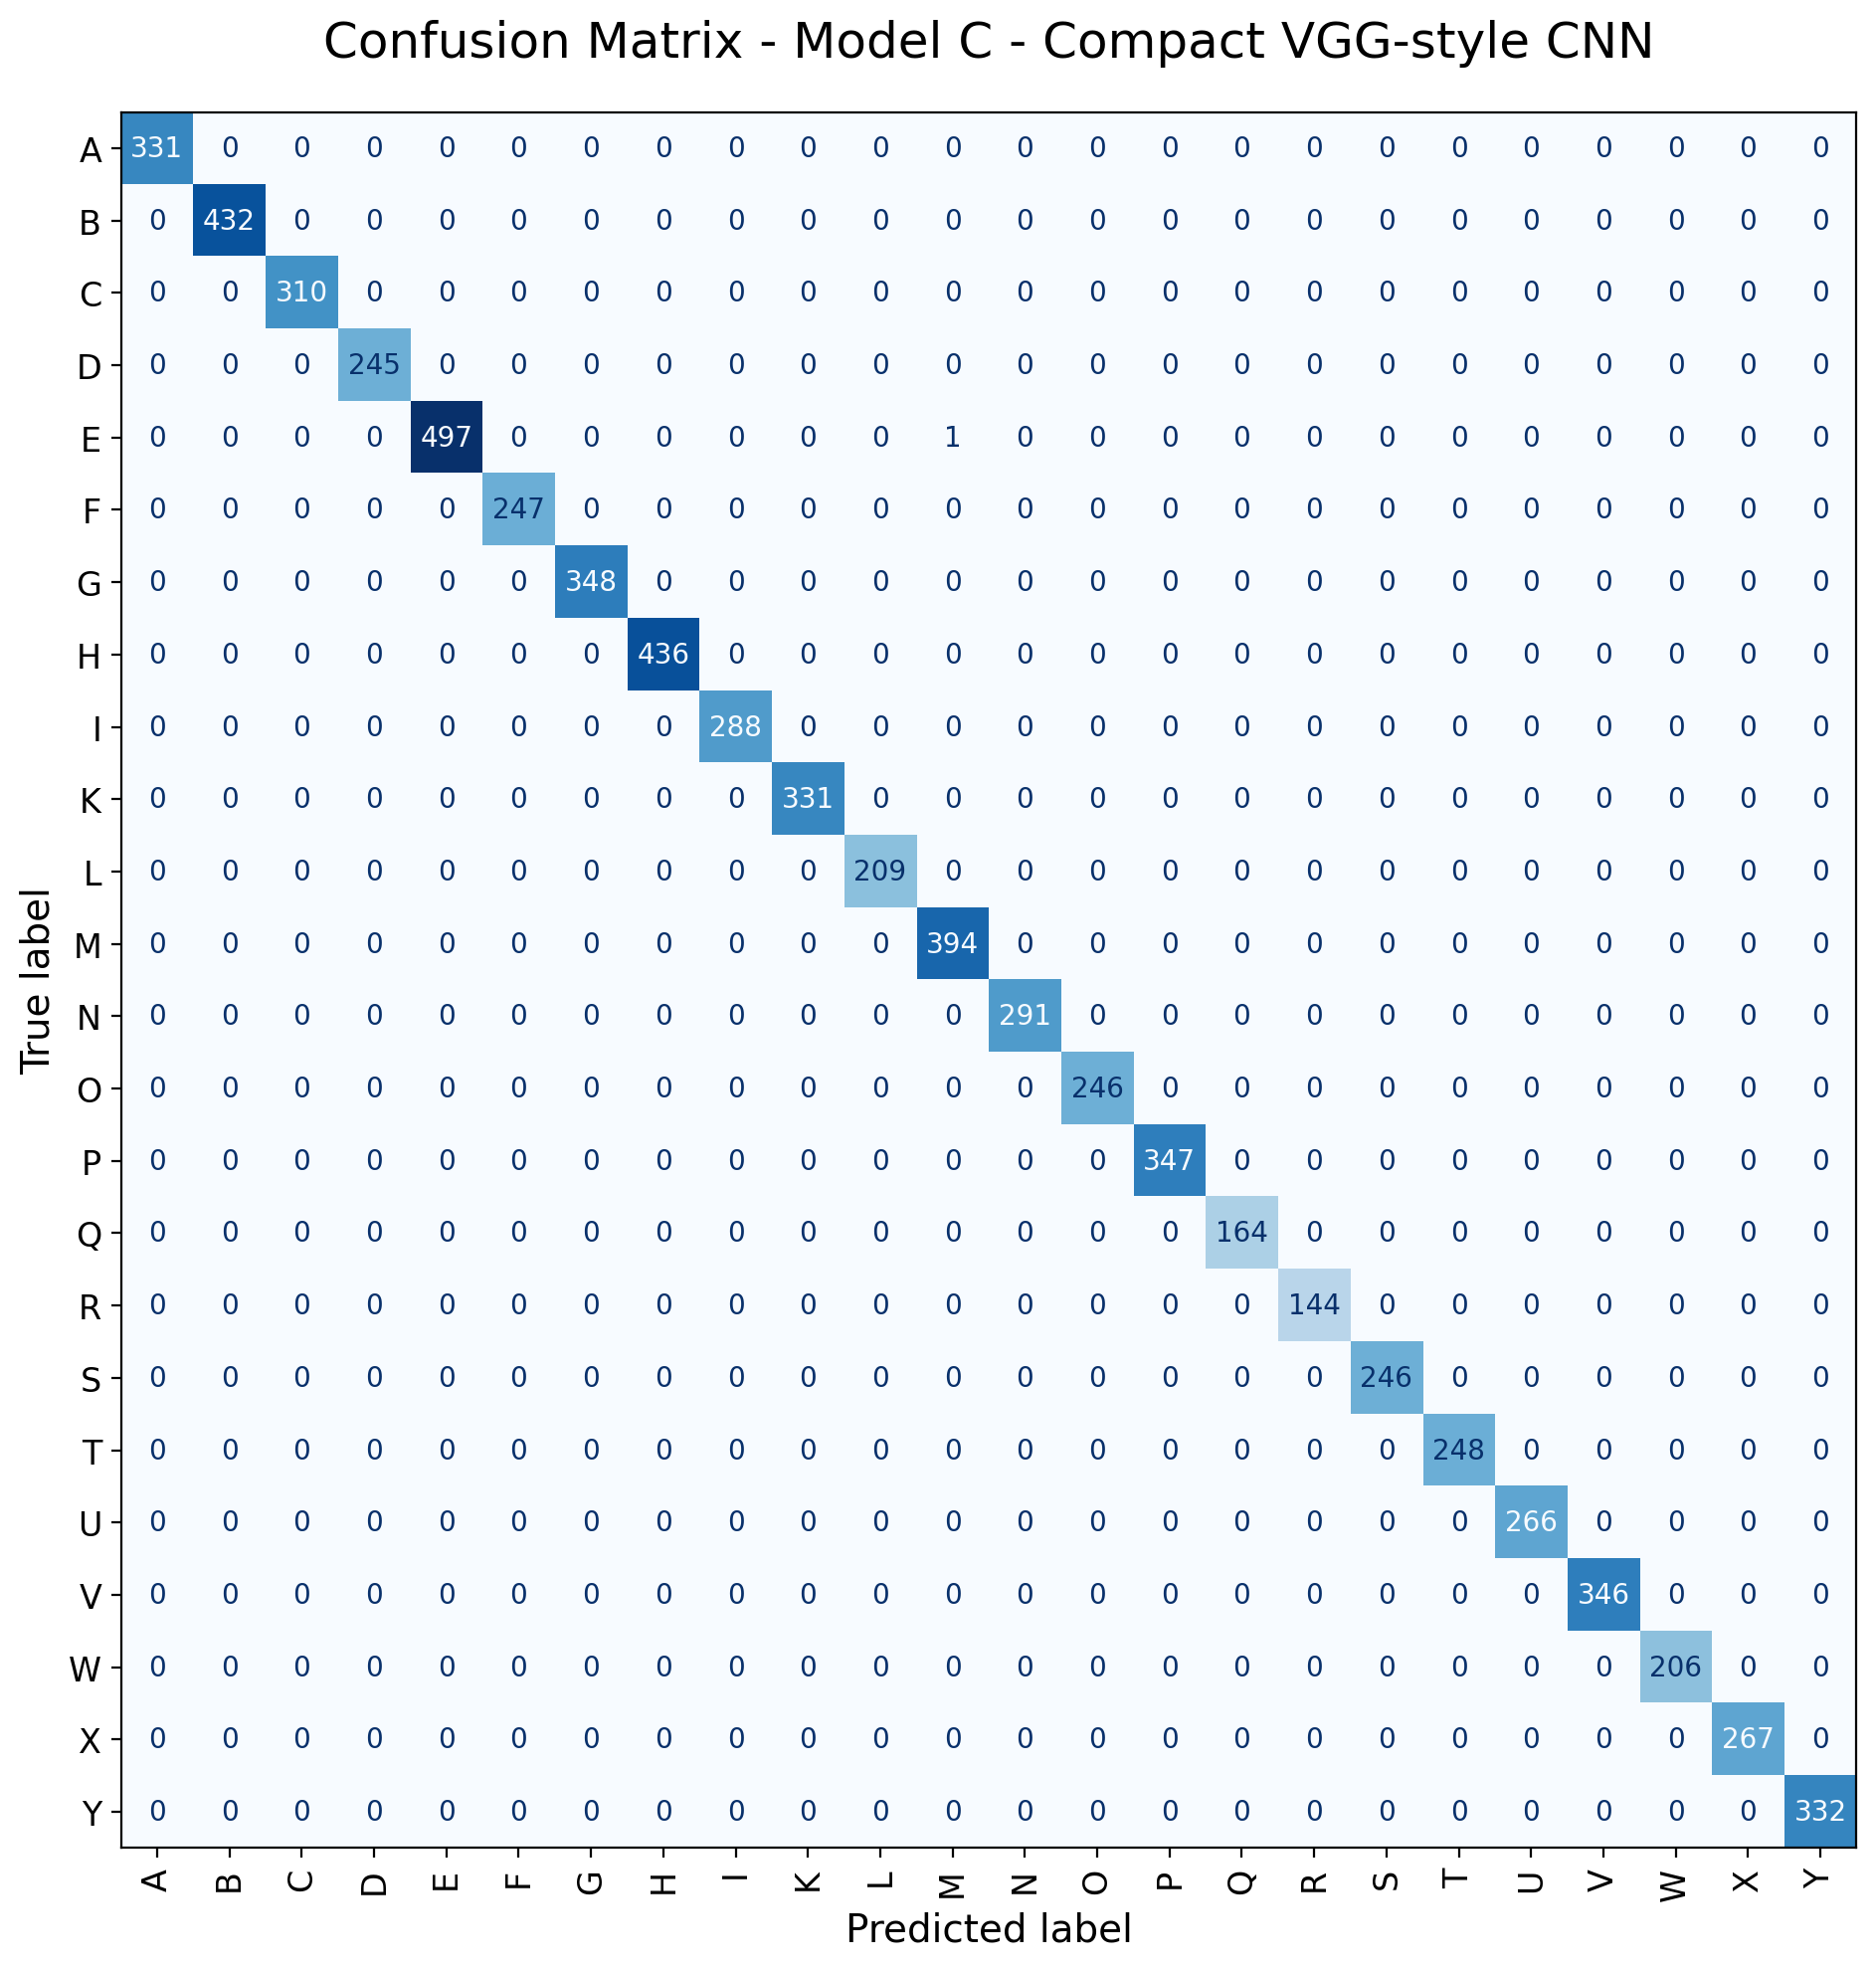

In [228]:
# 25. Confusion matrix for all 3 models
#    Larger and clearer version
all_confusion_matrices = {}

for model_name, y_pred in all_predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    all_confusion_matrices[model_name] = cm

    fig, ax = plt.subplots(figsize=(10, 10), dpi=200)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=target_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )

    plt.title(f"Confusion Matrix - {model_name}", fontsize=18, pad=20)
    plt.xlabel("Predicted label", fontsize=14)
    plt.ylabel("True label", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Safely increase the font size of the numbers inside the confusion matrix
    if disp.text_ is not None:
        for text in np.atleast_1d(disp.text_).flat:
            if text is not None:
                text.set_fontsize(10)

    plt.tight_layout()
    plt.show()

In [ ]:
# Hardest classes by recall for each model
# This shows which classes each model struggles with most

target_names = [idx_to_letter[i] for i in range(num_classes)]
ardest_classes_all = []

for model_name, y_pred in all_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    # Recall for each class = TP / actual class total
    per_class_recall = np.diag(cm) / cm.sum(axis=1)
    per_class_recall = np.nan_to_num(per_class_recall)

    model_hardest_df = pd.DataFrame({
        "Model": model_name,
        "Class": target_names,
        "Recall": per_class_recall
    }).sort_values(by="Recall", ascending=True).reset_index(drop=True)

    hardest_classes_all.append(model_hardest_df)

    print("\n" + "=" * 90)
    print(f"Hardest classes by recall - {model_name}")
    print("=" * 90)
    print(model_hardest_df.head(10))

hardest_classes_df = pd.concat(hardest_classes_all, ignore_index=True)


Hardest classes by recall - Model A - Baseline CNN
                    Model Class    Recall
0  Model A - Baseline CNN     Y  0.948795
1  Model A - Baseline CNN     B  0.962963
2  Model A - Baseline CNN     C  1.000000
3  Model A - Baseline CNN     A  1.000000
4  Model A - Baseline CNN     E  1.000000
5  Model A - Baseline CNN     F  1.000000
6  Model A - Baseline CNN     G  1.000000
7  Model A - Baseline CNN     D  1.000000
8  Model A - Baseline CNN     I  1.000000
9  Model A - Baseline CNN     K  1.000000

Hardest classes by recall - Model B - AlexNet-inspired CNN
                            Model Class  Recall
0  Model B - AlexNet-inspired CNN     A     1.0
1  Model B - AlexNet-inspired CNN     B     1.0
2  Model B - AlexNet-inspired CNN     C     1.0
3  Model B - AlexNet-inspired CNN     D     1.0
4  Model B - AlexNet-inspired CNN     E     1.0
5  Model B - AlexNet-inspired CNN     F     1.0
6  Model B - AlexNet-inspired CNN     G     1.0
7  Model B - AlexNet-inspired CNN     H   

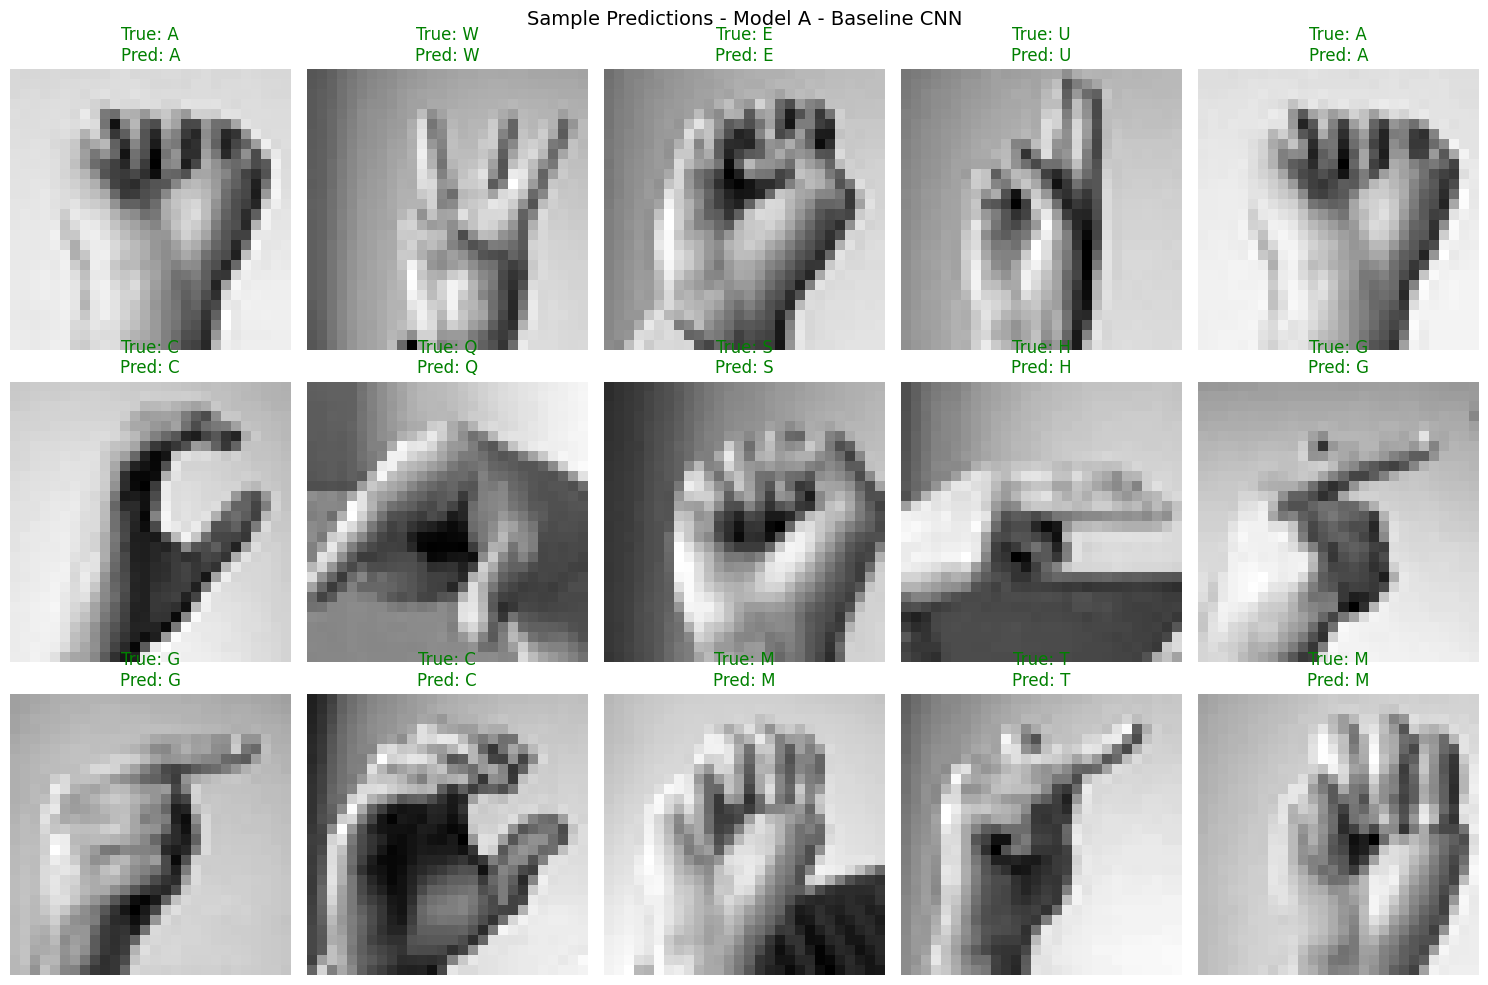

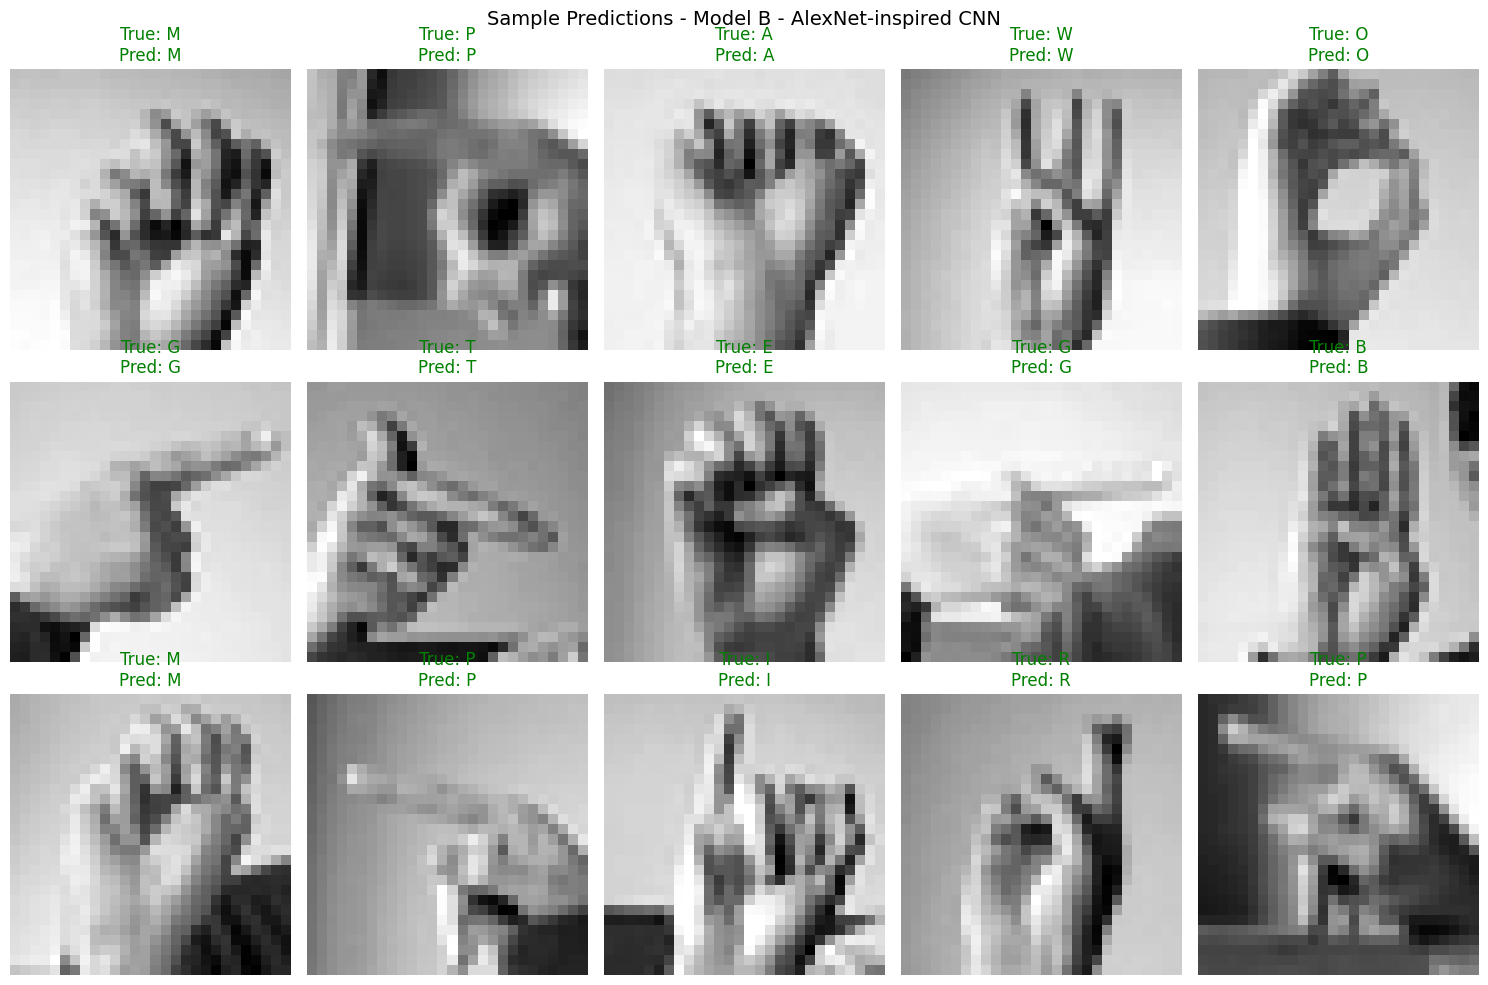

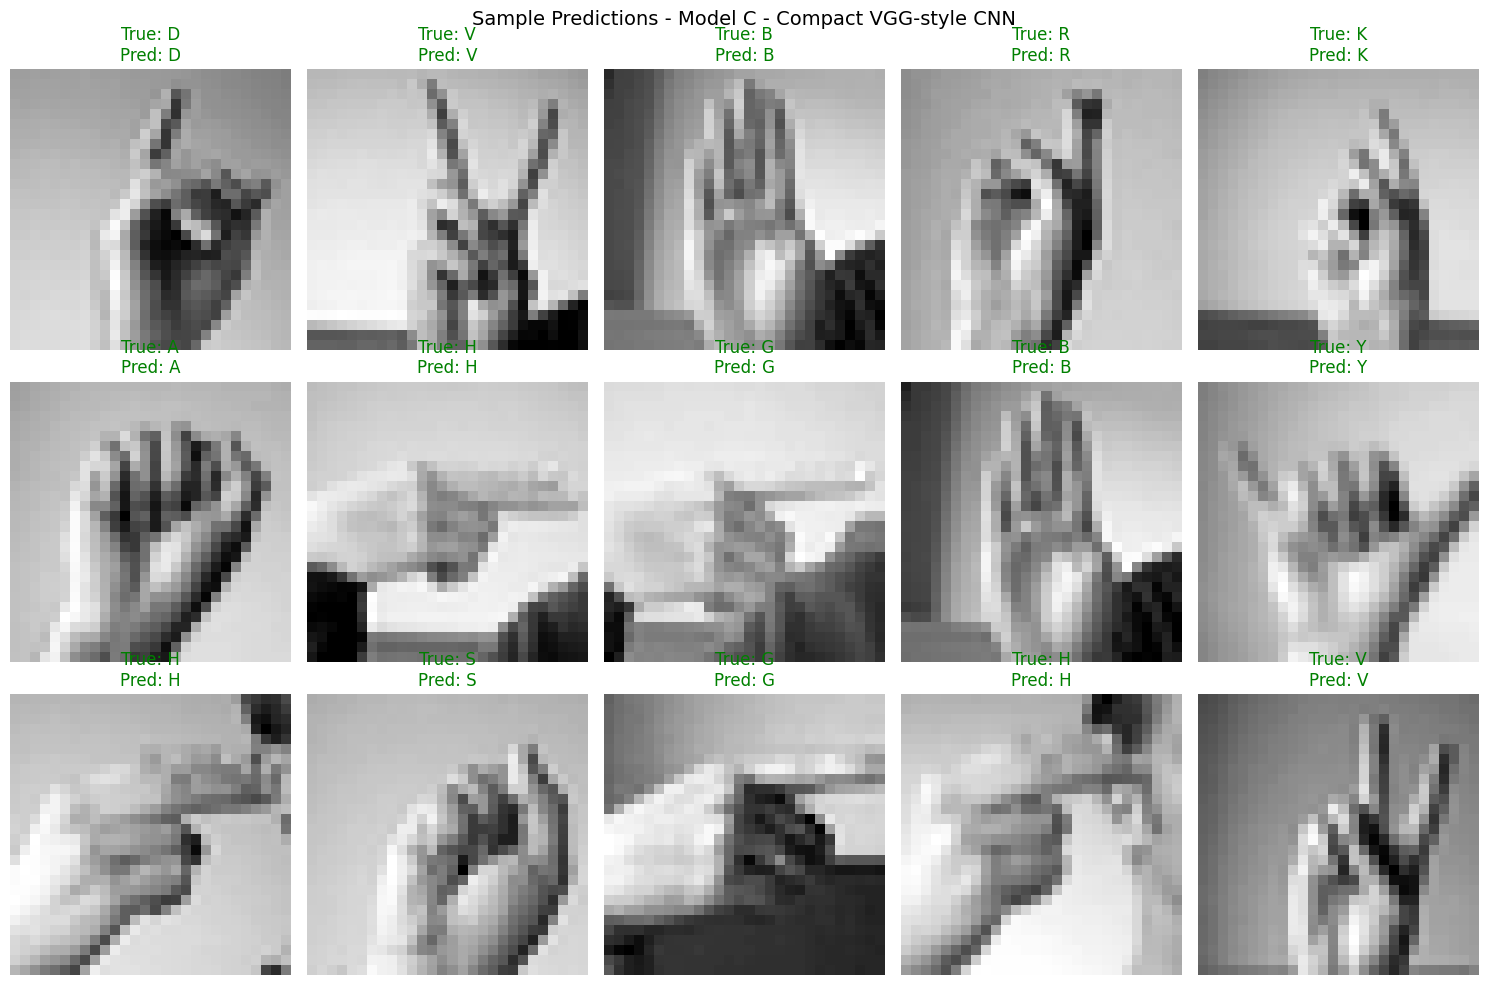

In [230]:
# =========================
# Sample predictions for all 3 models
# Shows:
# - test image
# - true label
# - predicted label
# - title color: green if correct, red if incorrect
# =========================

def show_sample_predictions(model, model_name, X_model_input, X_display, y_true, idx_to_letter, n=15):
    indices = np.random.choice(len(X_model_input), size=n, replace=False)

    X_sample_model = X_model_input[indices]
    X_sample_display = X_display[indices]
    y_sample_true = y_true[indices]

    y_sample_prob = model.predict(X_sample_model, verbose=0)
    y_sample_pred = np.argmax(y_sample_prob, axis=1)

    plt.figure(figsize=(15, 10))

    for i in range(n):
        plt.subplot(3, 5, i + 1)
        plt.imshow(X_sample_display[i].squeeze(), cmap="gray")

        true_label = idx_to_letter[y_sample_true[i]]
        pred_label = idx_to_letter[y_sample_pred[i]]

        title_color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
        plt.axis("off")

    plt.suptitle(f"Sample Predictions - {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Show sample predictions for each model
for model_name, model in trained_models.items():
    show_sample_predictions(
        model=model,
        model_name=model_name,
        X_model_input=X_test_full,
        X_display=X_test_display,
        y_true=y_test,
        idx_to_letter=idx_to_letter,
        n=15
    )